# Lab 8

#### Author: Esraaj Sarkar Gupta
#### Date: 15th March 2026

<Now THIS time Im sure Indrani maam wont notice this string of text>

In [6]:
# ---- Imports ---- #

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import balanced_accuracy_score, accuracy_score, classification_report, confusion_matrix

print("Imports complete...")

Imports complete...


In [22]:
# ---- Loading Data ---- #

data = pd.read_csv("data.csv")

# Peek at data
display(data.head())
display(data.info())

,Cancer stage,Clump thickness,No of week,Clump thickness_new,No of week_new,True cancer stage
0,1.0,10.510076,6.166544,10.269649,11.999203,1
1,1.0,11.739776,7.024066,10.494287,6.495638,1
2,1.0,7.857070,5.909366,8.516879,7.102108,1
3,1.0,10.817929,5.920890,8.979736,9.196251,1
4,1.0,10.302407,6.984937,9.553005,7.120283,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Cancer stage         200 non-null    float64
 1   Clump thickness      200 non-null    float64
 2   No of week           200 non-null    float64
 3   Clump thickness_new  2000 non-null   float64
 4   No of week_new       2000 non-null   float64
 5   True cancer stage    2000 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 93.9 KB


None

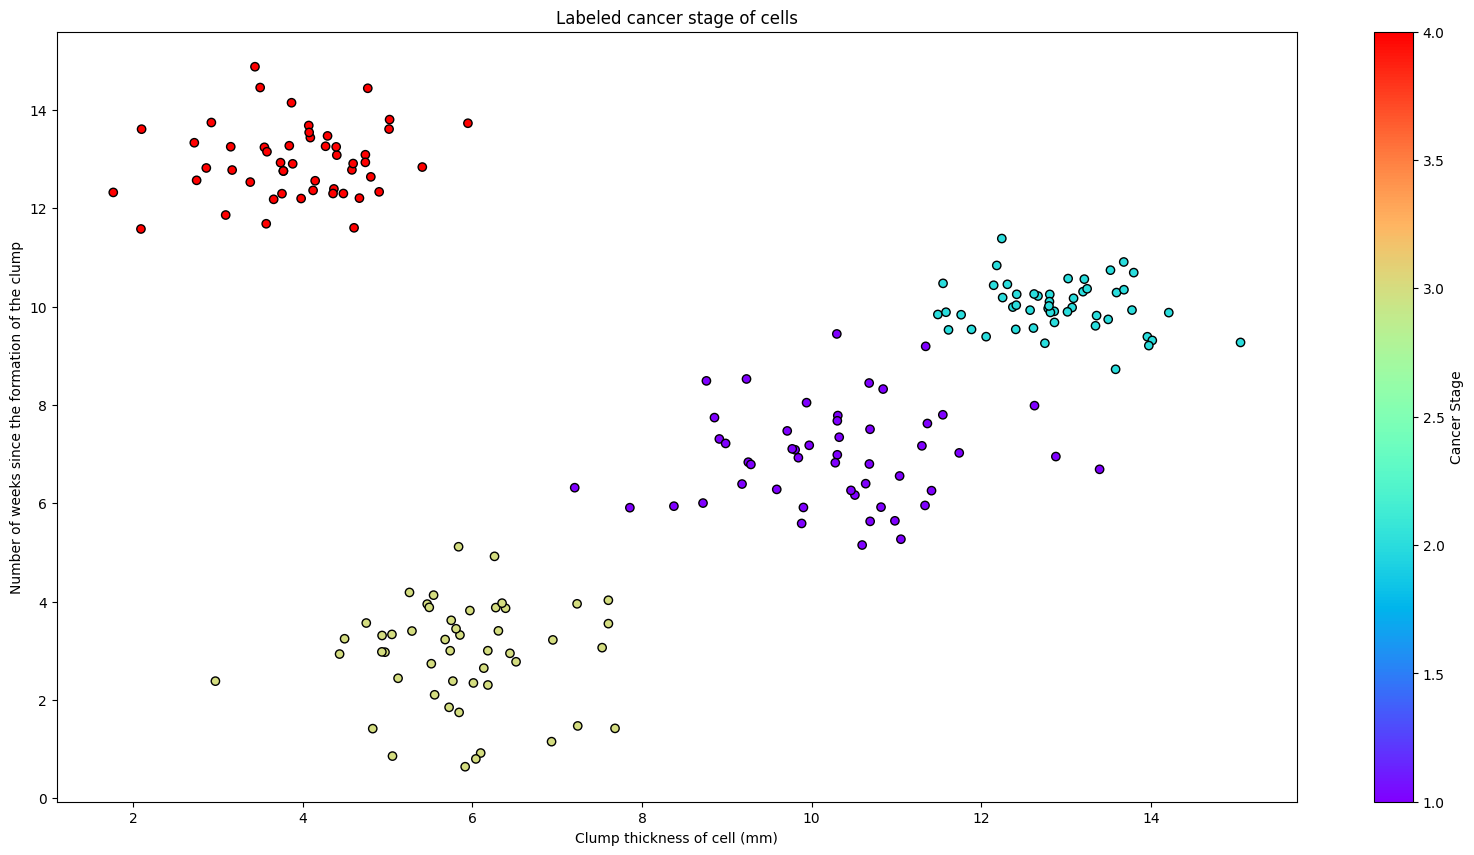

In [23]:
# ---- Visualize  Labeled Data ---- #
# Clump thickness vs number_of_week

# What a depressing topic to have to do an assignment on.
plt.figure(figsize=(20,10))

scatter = plt.scatter(
    data["Clump thickness"],
    data["No of week"],
    c=data["Cancer stage"],     # color by cancer stage
    cmap="rainbow",             # Life could be all rainbows and sunshine
    edgecolors="black"          # Pretty
)

plt.xlabel("Clump thickness of cell (mm)")
plt.ylabel("Number of weeks since the formation of the clump")
plt.title("Labeled cancer stage of cells")

plt.colorbar(scatter, label="Cancer Stage")

plt.show()

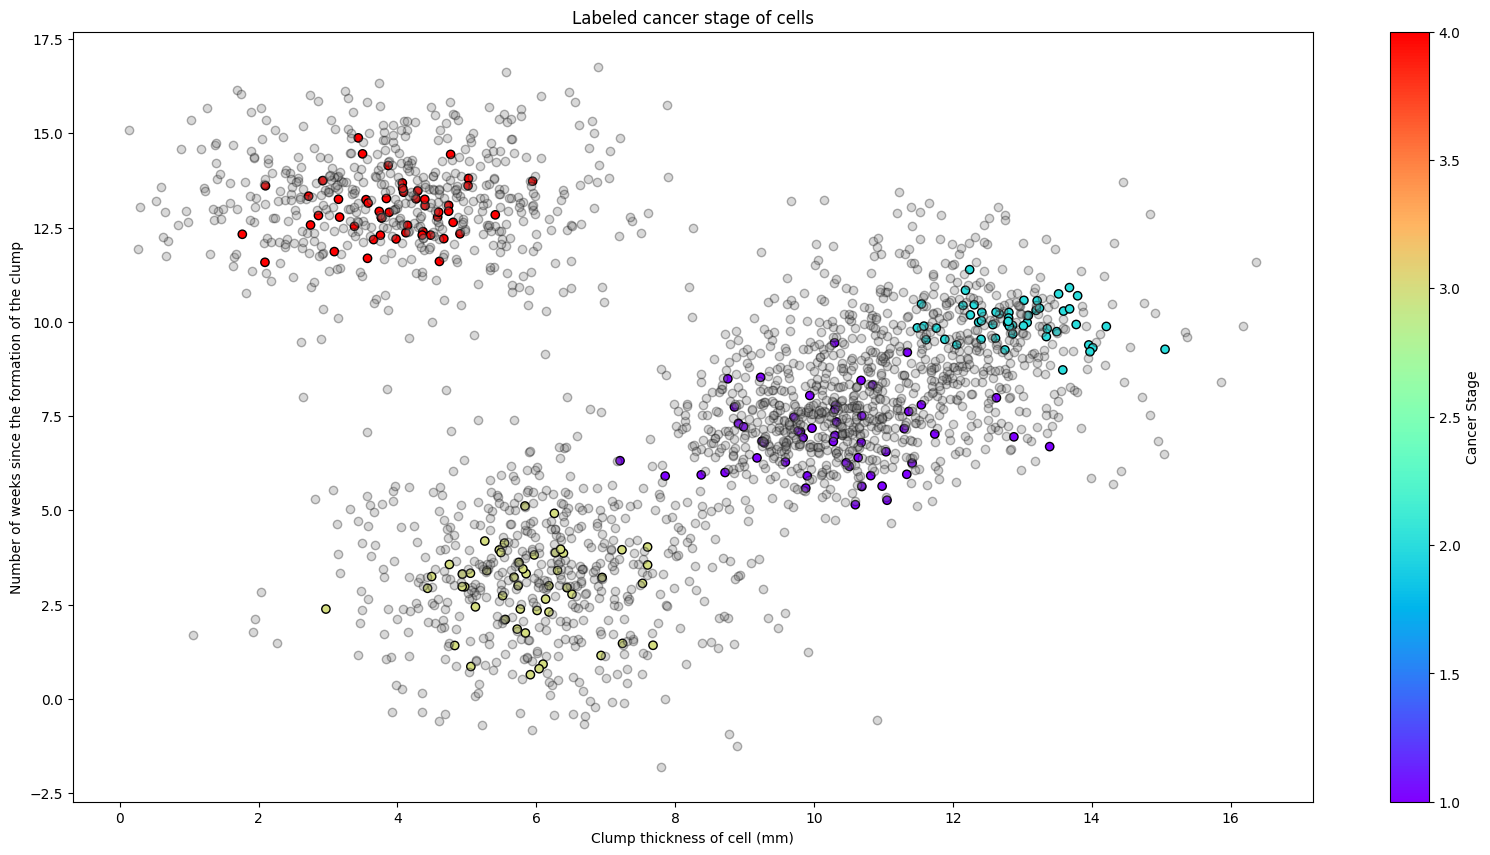

In [24]:
# ---- Overlay Unlabeled Data ---- #

plt.figure(figsize=(20,10))

# Labeled Data
scatter = plt.scatter(
    data["Clump thickness"],
    data["No of week"],
    c=data["Cancer stage"],     # color by cancer stage
    cmap="rainbow",             # Life could be all rainbows and sunshine
    edgecolors="black"          # Neat and pretty
)

# New, unlabeled data
plt.scatter(
    data["Clump thickness_new"],
    data["No of week_new"],
    color="grey",               # We're not sure where these belong yet
    edgecolors="black",         # Still neat and pretty
    alpha=0.3                   # 
)


plt.xlabel("Clump thickness of cell (mm)")
plt.ylabel("Number of weeks since the formation of the clump")
plt.title("Labeled cancer stage of cells")

plt.colorbar(scatter, label="Cancer Stage")

plt.show()

In [27]:
# ---- Training ---- #

# -- Setting up the Data -- #
labeled_data = data.dropna(subset=["Clump thickness", "No of week", "Cancer stage"])
unlabeled_data = data.dropna(subset=["Clump thickness_new", "No of week_new"])

# Labeled Features and Target
X_labeled = labeled_data[["Clump thickness", "No of week"]]
y_labeled = labeled_data["Cancer stage"].astype(int)

# Unlabeled Features (but no target :c)
X_unlabeled = unlabeled_data[["Clump thickness_new", "No of week_new"]].copy()
X_unlabeled.columns = ["Clump thickness", "No of week"]

# Concat features
X_all = pd.concat([X_labeled, X_unlabeled], ignore_index=True)

# Assign a dummy label to unbaled targets
y_unlabeled = np.full(len(X_unlabeled), -1)

# Combine labels
y_all = np.concatenate([y_labeled, y_unlabeled])


# -- The Base Estimator : KNeighbours -- #
knn = KNeighborsClassifier(n_neighbors=5) # "5 is a common default that balances bias and variance", and I like the number five.

# -- Self Training Model (Semi-Supervised) -- #
model = SelfTrainingClassifier(knn)

# Train the model
model.fit(X_all, y_all)

# Predict labels
predicted_labels = model.predict(X_unlabeled)

print("Done...")


Done...


Accuracy: 0.8915
Balanced Accuracy: 0.8915

Classification Report:
              precision    recall  f1-score   support

           1       0.71      0.98      0.82       500
           2       0.96      0.64      0.77       500
           3       1.00      0.96      0.98       500
           4       0.99      1.00      1.00       500

    accuracy                           0.89      2000
   macro avg       0.92      0.89      0.89      2000
weighted avg       0.92      0.89      0.89      2000


Confusion Matrix:
[[488  12   0   0]
 [182 318   0   0]
 [ 18   0 478   4]
 [  1   0   0 499]]


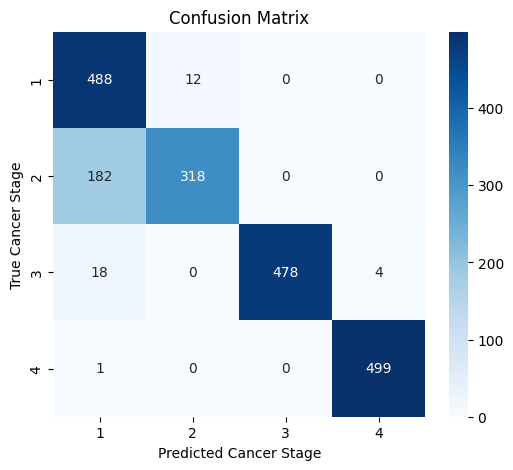

In [34]:
# ---- Evaluation ---- #

# True labels for the 2000 datapoints
y_true = unlabeled_data["True cancer stage"]

# Predictions
y_pred = predicted_labels

# Accuracy
acc = accuracy_score(y_true, y_pred)

# Balanced accuracy
bal_acc = balanced_accuracy_score(y_true, y_pred)

print("Accuracy:", acc)
print("Balanced Accuracy:", bal_acc)


# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

import seaborn as sns # Even though we weren't told to

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,          # Anotate
    fmt="d",             # integer format
    cmap="Blues",
    xticklabels=[1,2,3,4],
    yticklabels=[1,2,3,4]
)

plt.xlabel("Predicted Cancer Stage")
plt.ylabel("True Cancer Stage")
plt.title("Confusion Matrix")

plt.show()

In [36]:
# ---- Esraaj's Notes ---- #
# He wishes to keep them within the lab for his ease.
# Please forgive him.

"""
Semi-supervised learning is an ML paradigm that uses a combination
of a small amount of unlabeled data, and a large amount of unlabeled
data during training.

Pragmatically, it is easier to collect raw data than to label them. Labeling
requires time, money, expert knowledge (and other things we are reluctant to
provide).

In SSL, the model is trained on a labeled dataset. This information is used to
infer probable labels for the unlabeled data. These infered labeles can then be
incorporated into the training dataset.

Self-training, Co-training, Graph-based methods (etc).
"""

None

# Report

#### Question 1
Semi-supervised learning can be applied anywhere where large amount of labeled data are available, with limited labeled data; given that the model msut be used to predict labels for data. A prominent application (as demonstrated in this assignment) is medical analysis.

SSL can also be used in speech-recognition systems where large volumes of recordings are available, with only a small subset of these are transcribed.

A third application is web content classification. Web pages are abundant but only a few of them have been labeled with categories.

In all these cases, Semi-Supervised learning allows classification models to learn (and predict labels) from both labeled and unlabeled data.

#### Question 2 and Question 3
SSL relies on certain assumptions about the structure of the data.

* Smoothness Assumption : Data points that are close to each other in the feature space are liely to share the same label. This allows the algorithm to extend labels from labeled points to nearby unlabeled points.

* Cluster Assumption : Data points tend to form clusters, and points belonging to the same cluster are likely to have the same class label. This assumption allows the model to propagate labels within clusters.

* Manifold Assumption : High dimensional data often lies on a lower dimensional manifold. SSL models can exploint this underlying structure to better learn the classification boundaries. The model assumes that the meaningful data lies on a lower dimensional manifold within the feature space, allowing the algorithm to learn more accurate decision boundaries with limited labeled data.

#### Question 4
Self-training is a SSL technique where a single classifier is initially trained on labeled data and then used to predict unlabeled data. The most confident predictions are then added to the labeled dataset and used for training a supervised learning ML model. This process allows the classifier to gradually expand its training data.

In constrast to this, Co-Training uses two different classifiers on two different feature sets of the same data. Each classifier labels the unlabeled data for the other classifier; this allows the models to learn collaboratively. This approach is generally considered more robust since each classifer provides additional information to the other.

In many cases, Co-training can achieve better performance because it reduces the risk of reinforcing incorrect predictions. However, its effectiveness depends on the availability of two independent and sufficient feature views, which is not always possible.

#### Question 5

The performance of an SSL model can be evaluated by comparing the predicted labels with the true labels of a datapoint. Various evaluation metrics can be used for this purpose. Common metrics (such as ones included in this lab) are accuracy, balanced accuracy, precision, recall and F1-score. These metrics measure how well the model predicts the correct class labels.

A Confusion Matrix (implemented here) is also used to evaluate classification performance. Performance can be assessed using validation datasets or cross-validation techniques to evaluate how well the model generalizes to unseen data.
